# RNN/LSTM Image Captioning

In [15]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = next((p for p in [cwd, *cwd.parents] if (p / "src" / "rnn").exists()), cwd)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root: {REPO_ROOT}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Repo root: C:\Users\HP 14s\Documents\1_FARHAN\1.SEM_6\ML\tubes-2\Tubes2ML_KicauMania


In [16]:
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to C:\Users\HP
[nltk_data]     14s\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\HP
[nltk_data]     14s\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Configuration

In [ ]:
from src.rnn.paths import ARCH_TAG, RnnPaths

paths = RnnPaths.from_root(REPO_ROOT)
SEQ_LEN = 35
EVAL_LIMIT = 100
EPOCHS = 5
BATCH_SIZE = 64
RUN_TRAINING = False
RETRAIN_EXISTING_WEIGHTS = False
FORCE_FEATURE_EXTRACTION = False

print(f"Architecture: {ARCH_TAG}")


## Feature Extraction

In [18]:
from src.rnn.feature_extraction import extract_and_save_repo_features
from src.rnn.experiment import load_feature_map

features_exist = paths.features_file.exists() and paths.feature_names_file.exists()
if FORCE_FEATURE_EXTRACTION or not features_exist:
    features_matrix, image_names = extract_and_save_repo_features(
        REPO_ROOT,
        batch_size=32,
        force=FORCE_FEATURE_EXTRACTION,
    )
else:
    print(f"Feature cache found: {paths.feature_dir}")

raw_image_features_map = load_feature_map(REPO_ROOT)
print(f"Loaded {len(raw_image_features_map)} raw image feature vectors")


Feature cache found: C:\Users\HP 14s\Documents\1_FARHAN\1.SEM_6\ML\tubes-2\Tubes2ML_KicauMania\images_feature
Loaded 8091 raw image feature vectors


## Caption Data

In [19]:
from src.rnn.experiment import load_caption_sequences, load_text_util
from src.rnn.training import prepare_training_data

text_util = load_text_util(REPO_ROOT, sequence_length=SEQ_LEN)
caption_mapping, sequence_mapping = load_caption_sequences(REPO_ROOT, text_util)
training_data = prepare_training_data(REPO_ROOT, sequence_length=SEQ_LEN)
image_features_map = training_data["image_features"]

print(f"Vocabulary size: {text_util.vocab_size}")
print(f"Captions mapped: {len(caption_mapping)} images")
print(f"Train/val/test: {len(training_data['train_keys'])}/{len(training_data['val_keys'])}/{len(training_data['test_keys'])}")
print(f"Scaled feature vectors ready: {len(image_features_map)}")


Vocabulary size: 8587
Captions mapped: 8091 images
Train/val/test: 6000/1000/1091
Scaled feature vectors ready: 8091


## Keras Training

In [ ]:
from src.rnn.experiment import load_training_history
from src.rnn.training import train_all_variations, training_artifacts_complete

if RUN_TRAINING or not training_artifacts_complete(REPO_ROOT):
    history_df = train_all_variations(
        REPO_ROOT,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        sequence_length=SEQ_LEN,
        retrain_existing=RETRAIN_EXISTING_WEIGHTS,
    )
else:
    history_df = load_training_history(REPO_ROOT)

display_columns = [
    "architecture", "model_type", "variation_name", "layers", "hidden_state",
    "final_loss", "final_val_loss", "training_time_sec", "weight_file", "training_status",
]
history_df[[column for column in display_columns if column in history_df.columns]]

## Scratch Caption Smoke Test

In [ ]:
from src.rnn.ImageCaptioningScratch import ImageCaptioningModel
from src.rnn.experiment import make_keras_model

keras_model = make_keras_model(REPO_ROOT, text_util, "LSTM", "Shallow_Small", 1, 128)
scratch_model = ImageCaptioningModel(keras_model, text_util, is_lstm=True)

sample_image = training_data["test_keys"][0]
sample_caption = scratch_model.generate_caption(image_features_map[sample_image], max_len=10)
print(sample_image)
print(sample_caption)



2736508369_fd9ff0b42f.jpg
a dog in a dog


## Full Evaluation

In [ ]:
from src.rnn.experiment import (
    assert_anti_collapse_acceptance,
    compare_best_keras_vs_scratch,
    evaluate_all_variations,
    max_length_sweep,
    qualitative_samples,
    write_analysis_summary,
)


In [ ]:
variation_results, caption_details = evaluate_all_variations(
    REPO_ROOT,
    split="test",
    limit=EVAL_LIMIT,
    max_len=SEQ_LEN,
)
variation_results.sort_values(["model_type", "scratch_bleu_4"], ascending=[True, False])

,model_type,variation_name,layers,hidden_state,scratch_bleu_4,scratch_meteor,scratch_total_time_sec,scratch_avg_time_sec,training_time_sec,final_loss,final_val_loss
6,LSTM,Shallow_Small,1,128,0.090163,0.221113,3.399609,0.033996,723.841481,1.602262,1.555027
9,LSTM,Shallow_Mid,1,256,0.016778,0.166550,37.726391,0.377264,1344.518378,1.484849,1.460933
8,LSTM,VeryDeep_Small,3,128,0.013001,0.106174,13.488404,0.134884,1199.804506,1.801831,1.744137
11,LSTM,Deep_Large,2,512,0.011214,0.128433,154.682930,1.546829,4411.692248,1.575237,1.546189
10,LSTM,Shallow_Large,1,512,0.011029,0.137277,88.823823,0.888238,2823.215855,1.446680,1.433557
7,LSTM,Deep_Small,2,128,0.006424,0.091279,21.657192,0.216572,835.507474,1.737048,1.719244
2,SimpleRNN,VeryDeep_Small,3,128,0.070621,0.241786,4.396504,0.043965,810.964165,1.406949,1.375105
3,SimpleRNN,Shallow_Mid,1,256,0.064313,0.251091,11.985182,0.119852,1008.595458,1.342779,1.342307
5,SimpleRNN,Deep_Large,2,512,0.063769,0.219759,29.072469,0.290725,1668.012844,1.355230,1.370123
1,SimpleRNN,Deep_Small,2,128,0.060209,0.215684,4.765949,0.047659,1149.691439,1.405146,1.379772


In [ ]:
keras_vs_scratch = compare_best_keras_vs_scratch(
    REPO_ROOT,
    split="test",
    limit=EVAL_LIMIT,
    max_len=SEQ_LEN,
)
keras_vs_scratch

,model_type,variation_name,layers,hidden_state,implementation,bleu_4,meteor,total_time_sec,avg_time_sec
0,LSTM,Shallow_Small,1,128,scratch,0.090163,0.221113,4.097924,0.040979
1,LSTM,Shallow_Small,1,128,keras,0.090669,0.222922,108.980176,1.089802
2,SimpleRNN,VeryDeep_Small,3,128,scratch,0.070621,0.241786,5.325038,0.053250
3,SimpleRNN,VeryDeep_Small,3,128,keras,0.069037,0.250317,136.072823,1.360728


In [ ]:
max_length_results = max_length_sweep(
    REPO_ROOT,
    lengths=(10, 20, 35),
    split="test",
    limit=EVAL_LIMIT,
)
max_length_results

,model_type,variation_name,implementation,max_len,bleu_4,meteor,total_time_sec,avg_time_sec
0,LSTM,Shallow_Small,keras,10,0.090669,0.222922,98.398456,0.983985
1,LSTM,Shallow_Small,keras,20,0.090669,0.222922,103.223196,1.032232
2,LSTM,Shallow_Small,keras,35,0.090669,0.222922,100.789012,1.007890


In [ ]:
samples = qualitative_samples(REPO_ROOT, limit=EVAL_LIMIT, n_per_bucket=4)
samples

,image_name,bleu_4_LSTM,bleu_4_SimpleRNN,generated_caption_LSTM,generated_caption_SimpleRNN,avg_bleu_4,ground_truth
0,3726170067_094cc1b7e5.jpg,0.668740,0.083070,a man in a dog,a dog is running in a water,0.375905,<start> a balding man with glasses stands in f...
1,3724718895_bd03f4a4dc.jpg,0.131558,0.537285,a man in a dog,a dog is running in a water,0.334422,<start> a dog drinks the sprinkler water <end>...
2,3723690961_729dd5d617.jpg,0.367012,0.072012,a man in a dog,a dog is running in a water,0.219512,<start> a man in a pink shirt and white vest p...
3,3737492755_bcfb800ed1.jpg,0.367012,0.072012,a man in a dog,a dog is running in a water,0.219512,<start> a man dressed in an indian costume pla...
4,3721799573_2f470950e0.jpg,0.000000,0.000000,a man in a dog,a dog is running in a water,0.000000,<start> there are two ladies embracing and pos...
5,3739833689_a0038545bd.jpg,0.015756,0.021281,a man in a dog,a dog is running in a water,0.018519,<start> a little boy puts a bat on his forehea...
6,380515798_c2abbf46b0.jpg,0.023505,0.025589,a man in a dog,a dog is running in a water,0.024547,<start> a crowd walks along a sidewalk of a fa...
7,3721881082_afe9fc734e.jpg,0.023505,0.028319,a dog in a dog,a dog is running in a water,0.025912,<start> a woman and a girl sitting on a front ...
8,3722507770_0d6cb7420e.jpg,0.069009,0.072012,a man in a dog,a dog is running in a water,0.070511,<start> a boy and his bike leaps into the air ...
9,3728256505_7f8db8270d.jpg,0.102950,0.039281,a man in a dog,a dog is running in a water,0.071116,<start> a man jumping onto a platform <end> | ...


In [ ]:
acceptance = assert_anti_collapse_acceptance(REPO_ROOT)
display(acceptance[["model_type", "variation_name", "unique_captions", "top_caption_frequency"]])

summary_path = write_analysis_summary(REPO_ROOT)
print(f"Ringkasan analisis disimpan di: {summary_path}")


Ringkasan analisis disimpan di: C:\Users\HP 14s\Documents\1_FARHAN\1.SEM_6\ML\tubes-2\Tubes2ML_KicauMania\artifacts\rnn\results\analysis_summary.md


## Training Curves

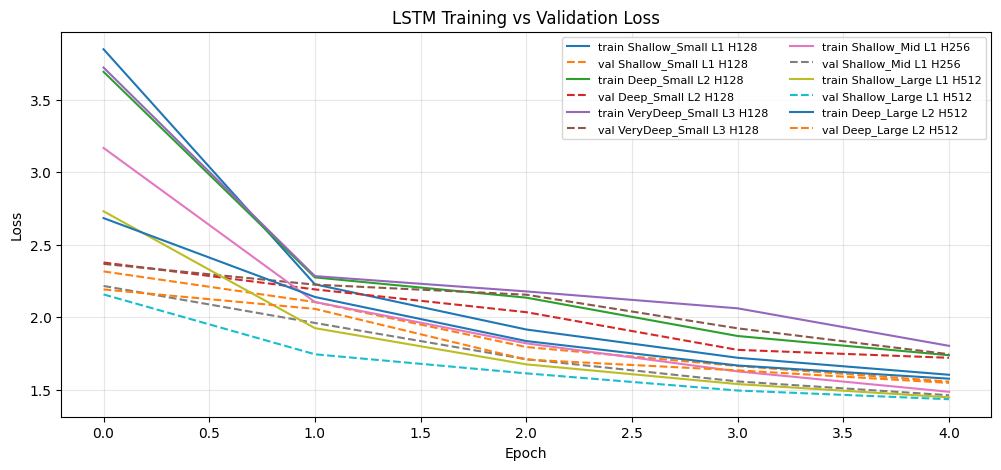

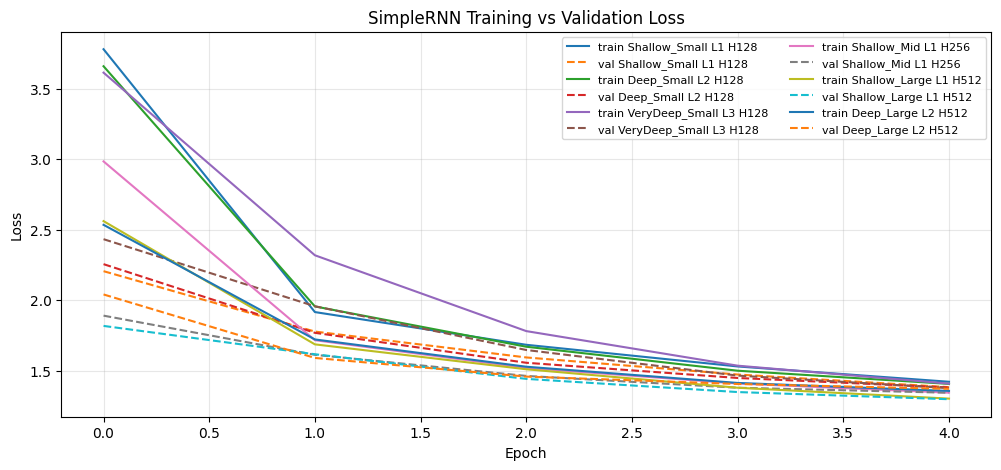

In [ ]:
from src.rnn.visualization import plot_training_history

plot_training_history(REPO_ROOT)